### EXAPLE PAG 34 IEEE 738 2023: Transient temperature calculation

In [1]:
%load_ext autoreload
%matplotlib widget
%autoreload 2
from   data_models.test_SS_models import get_models_test_SS
from   data_models.test_SS_data   import get_data_test_SS
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dt_data   = 10    # weather data sampling                  (min)
dt_interp = 10    # interpolation for integration sampling (s)
t_data    = np.arange(4)*dt_data*60 # (s)

Ta = 40   * np.ones_like(t_data)
Ws = 0.6  * np.ones_like(t_data) 
Wd = 90   * np.ones_like(t_data)
IT = 0    * np.ones_like(t_data) 
I1 = 1200 * np.ones_like(t_data) 
I2 = 1400 * np.ones_like(t_data) 
print_balance = True

MODE = 3
data = get_data_test_SS(MODE=MODE)
model_cigre, model_ieee1 = get_models_test_SS(data)
model_cigre, model_ieee2 = get_models_test_SS(data)

I_1 = model_ieee1.SS_Thermal_Rating(print_out=print_balance);
T_1 = model_ieee1.SS_Conductor_Temperature(print_out=print_balance);

I_2 = model_ieee2.SS_Thermal_Rating(print_out=print_balance);
T_2 = model_ieee2.SS_Conductor_Temperature(print_out=print_balance);


print('E3 TRANSIENT TEMPERATURE TRACKING CALCULATION STEPS')
print('*'*50)
t_tran1, T_tran1, data_tran2 = model_ieee1.TRAN_Conductor_Temperature(t_data, Ws, Wd, Ta, I1, IT, dt_tran=dt_interp, print_out=False,mode="Step");
t_tran2, T_tran2, data_tran2 = model_ieee2.TRAN_Conductor_Temperature(t_data, Ws, Wd, Ta, I2, IT, dt_tran=dt_interp, print_out=False,mode="Step");


**********************************************************************
STEADY-STATE THERMAL RATING: IEEE738
**********************************************************************
INPUT:  steady state temperature:  100.0000 °C
OUTPUT: steady state current:      1025.3612 A

Heat convective:    82.08310 W/m
Heat radiative:     39.10545 W/m
Heat joule:         98.72848 W/m
Heat solar:         22.46007 W/m --> shape=()
Rac:                 9.39050e-05 Ω/m
**********************************************************************

**********************************************************************
STEADY-STATE CONDUCTOR TEMPERATURE: IEEE738
**********************************************************************
INPUT:  steady state current:      1025.3612 A
OUTPUT: steady state temperature:  100.0000 °C

Heat convective:    82.08310 W/m
Heat radiative:     39.10545 W/m
Heat joule:         98.72848 W/m
Heat solar:         22.46007 W/m --> shape=()
Rac:                 9.39050e-05 Ω/m
*********

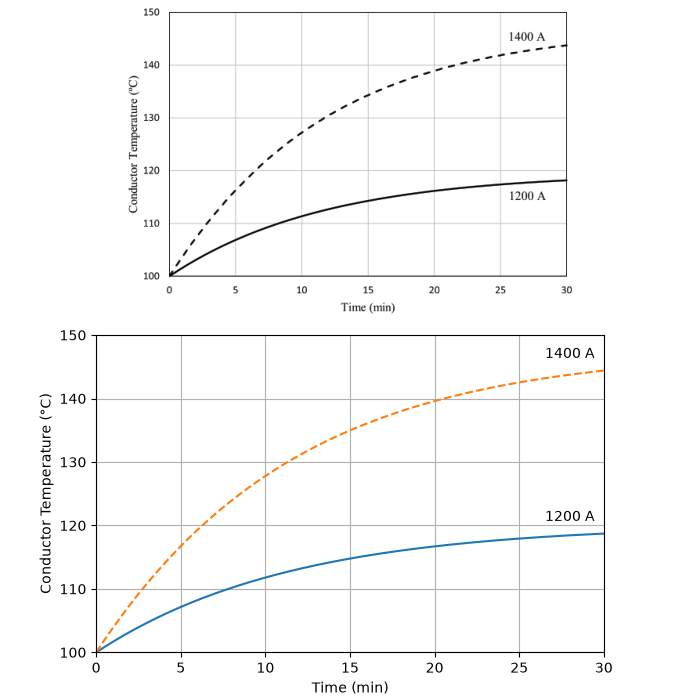

In [3]:
s        = 7
ar       = 1
fig, ax  = plt.subplots(2,1,constrained_layout=True,figsize=(ar*s,s))


ax[0].imshow( plt.imread('./imgs/tran_ieee.png'))
ax[0].axis('off')


ax[1].plot(t_tran1/60, T_tran1, label='1200 A')
ax[1].plot(t_tran2/60, T_tran2, label='1400 A',ls='--') 
ax[1].text(t_tran1[-1]/60-2,T_tran1[-1]+2,'1200 A',ha='center')
ax[1].text(t_tran2[-1]/60-2,T_tran2[-1]+2,'1400 A',ha='center')
ax[1].set_xlabel('Time (min)')
ax[1].set_ylabel('Conductor Temperature (°C)')
ax[1].set_yticks(np.arange(100,150+10,10))
ax[1].set_xticks(np.arange(0,30+5,5))
ax[1].set_ylim(100,150)
ax[1].set_xlim(0,30)
ax[1].set_box_aspect(1/1.6)
ax[1].grid()

